<a href="https://colab.research.google.com/github/tisenres/amity-aiml303/blob/main/Lab_Implementing_GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing GANs — Hands-on Training of a Simple GAN for Image Generation
---

## Learning objectives

By the end of this lab, you will be able to:

- Explain the **minimax game** between a **generator** $G$ and **discriminator** $D$, and interpret the **value function** used in the original GAN formulation.
- Implement a **vanilla GAN** in PyTorch using **MLPs** on **MNIST** (flattened images).
- Train with **BCE loss**, **Adam**, and **proper label tensors** for real vs. fake samples.
- Visualize **generated samples** and **loss curves**, and connect trends to **training stability**.
- Apply practical **stabilization ideas** (e.g., weight initialization, label smoothing) and **experiment** with architecture and data.

---

## GAN theory (compact refresher)

Generative Adversarial Networks (Goodfellow et al., 2014) frame generation as a **two-player game**:

- **Generator** $G(z)$ maps random noise $z \sim p_z$ (e.g., Gaussian) to data-like samples (here, fake MNIST digits).
- **Discriminator** $D(x)$ outputs a **probability** that input $x$ is **real** (from the dataset) rather than **fake** (from $G$).

**Value function (vanilla GAN, conceptual):**

$$\min_G \max_D \; V(D,G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

- $D$ tries to **maximize** $\log D(x)$ on real data and **minimize** $D(G(z))$ on fakes (equivalently maximize $\log(1-D(G(z)))$).
- $G$ tries to **fool** $D$, minimizing $\log(1-D(G(z)))$, often implemented by minimizing $-\log(D(G(z)))$ (**non-saturating** generator objective) for stronger gradients when $D$ is confident.

In this lab we use **binary cross-entropy** (`BCELoss`) with **target 1** for real and **target 0** for fake when training $D$; for $G$ we use fake samples with target **1** ("want discriminator to think fake is real").

---

## Prerequisites

- Comfortable with **PyTorch** basics: `nn.Module`, `optim`, tensors, `device` placement.
- Understanding of **binary classification** and **sigmoid + BCE**.
- Familiarity with **MNIST** / image tensors (optional: convolutional GANs are *not* required here — we use **MLPs** on **flattened** images).

## Environment

- **Google Colab** or local **Jupyter** with **PyTorch** + **torchvision** + **matplotlib** + **numpy**.
- Enable **GPU** in Colab (**Runtime → Change runtime type → GPU**) for faster training; the notebook runs on **CPU** as well, only slower.

> Run cells **in order** the first time through.


---

# Tutorial: Step-by-Step Implementation of a Vanilla GAN

This section walks you from **data** → **models** → **training** → **visualization**. Read the markdown between code cells: it explains *what* each block does and *why*.


### Setup: imports, reproducibility, and device

We fix **random seeds** for reproducibility (results may still vary slightly across hardware). **`torch.cuda.is_available()`** selects **GPU** when present.


In [ ]:
# Cell: imports, seed, device
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


**What you should see:** a one-line print with `cuda` (GPU) or `cpu`. All later tensors and models will be moved to this `device`.


### Data: MNIST, flattened and scaled to [-1, 1]

- **`ToTensor()`** gives floats in **[0, 1]**.
- We **flatten** to 784-D vectors with **`Lambda`**.
- **GANs** often use **Tanh** outputs; matching the data range to **[-1, 1]** works well: `x' = 2x - 1`.

**Batch size** is **128** as specified.


In [ ]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),  # flatten to 784
    transforms.Lambda(lambda x: 2.0 * x - 1.0),  # [0,1] -> [-1,1]
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform,
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f"MNIST train samples: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.40MB/s]

MNIST train samples: 60000
Batches per epoch: 468


**Takeaway:** each batch has shape **`(128, 784)`** after flattening. Discriminator sees **vectors**; this is a **vanilla MLP GAN**, not DCGAN.


### Models: MLP Generator and Discriminator

**Generator:** noise dimension **`nz = 100`**. Hidden layers use **LeakyReLU** (small slope for negative inputs helps gradients). Output is **784** with **Tanh** so outputs lie in **[-1, 1]** (matching images).

**Discriminator:** maps **784 → 1** with **Sigmoid** (probability "real").

**Weight initialization:** small Gaussian noise for weights; zeros for biases — a common starting point (you may compare with default init in the exercises).


In [ ]:
nz = 100  # noise dimension

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    def __init__(self, nz: int = 100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nz, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


G = Generator(nz).to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

print(G)
print(D)


Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


**Sanity check:** parameter counts should be modest (MLPs on 784-D). If shapes mismatch later, re-check **784** and **`nz`**.


### Loss and optimizers

- **`BCELoss`** matches **sigmoid** outputs.
- **Adam** with **`lr=2e-4`**, **`betas=(0.5, 0.999)`** — **beta1 = 0.5** is a common heuristic for GANs (less momentum than default 0.9).

**Labels:** real batch → **1**, fake batch → **0** when training **D**; for **G**, we pass **fakes** with target **1**.


In [ ]:
criterion = nn.BCELoss()
lr = 0.0002
betas = (0.5, 0.999)

optimizerD = optim.Adam(D.parameters(), lr=lr, betas=betas)
optimizerG = optim.Adam(G.parameters(), lr=lr, betas=betas)


Separate optimizers let us update **D** and **G** on **different** objectives while sharing the same hyperparameters unless you choose otherwise in the exercises.


### Visualization helpers

We will plot **64** generated digits in an **8×8** grid and track **mean** generator/discriminator loss per epoch.


In [ ]:
def denormalize_to_01(x: torch.Tensor) -> torch.Tensor:
    """Map from [-1, 1] back to [0, 1] for plotting."""
    return (x + 1.0) / 2.0


The training loop below uses **`torch.no_grad()`** when rendering snapshots so we **do not** build computation graphs for visualization-only forwards.


### Training loop (50 epochs)

Each epoch:

1. **Update D:** classify real vs fake.
2. **Update G:** maximize $\log D(G(z))$ via **fake labeled as real**.

We log **mean losses** per epoch. Every **5 epochs** we show samples and plot **loss curves so far**.

**Stability tips (commented in code):** balanced updates, **detach** fake tensors when training **D**, optional mild **label smoothing** on real labels for **D** only (see comments — default off for baseline clarity).


Epoch [01/50]  Loss_G: 2.0315  Loss_D: 0.3659


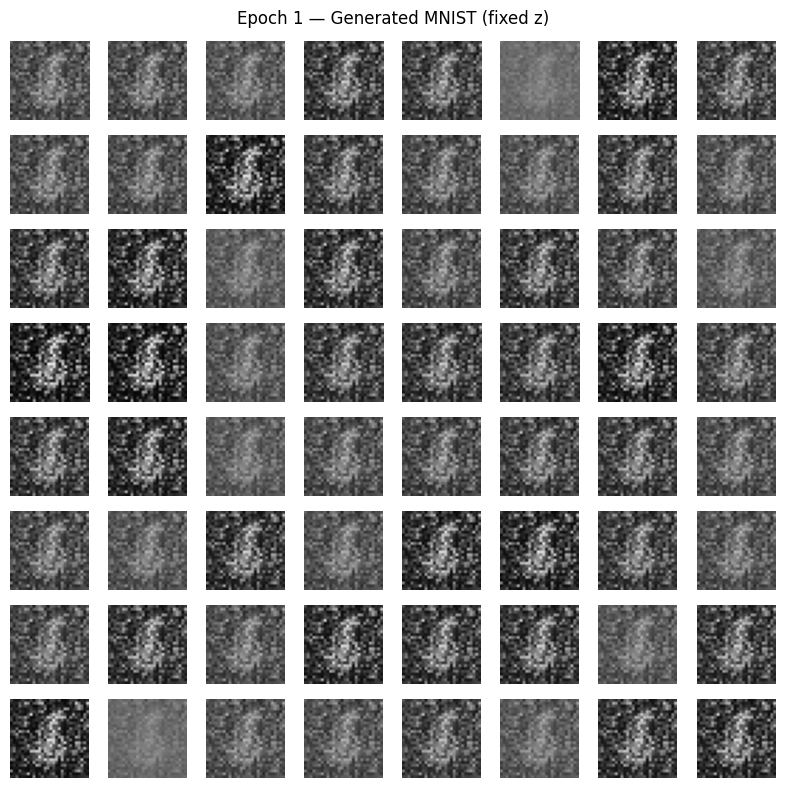

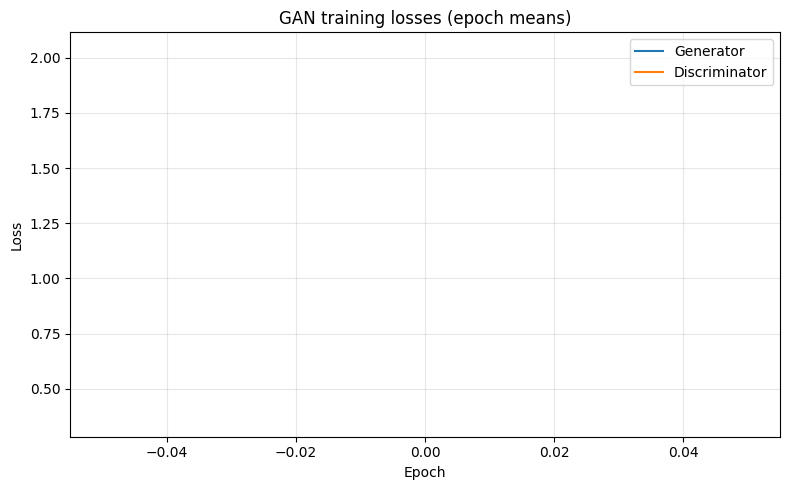

Epoch [02/50]  Loss_G: 4.0056  Loss_D: 0.2403
Epoch [03/50]  Loss_G: 3.4728  Loss_D: 0.2382
Epoch [04/50]  Loss_G: 3.7377  Loss_D: 0.1917
Epoch [05/50]  Loss_G: 3.6933  Loss_D: 0.1453


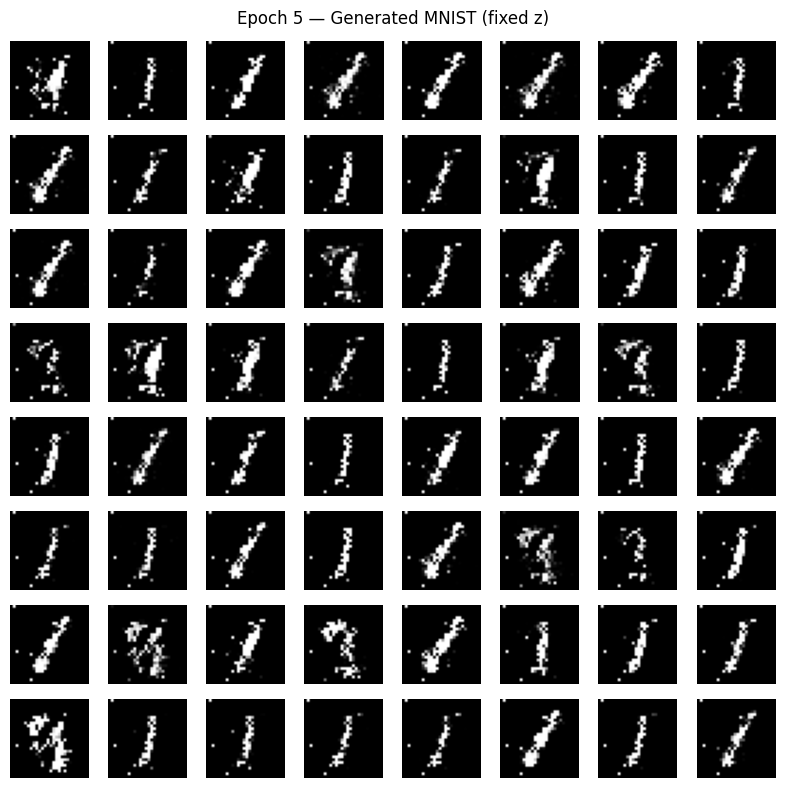

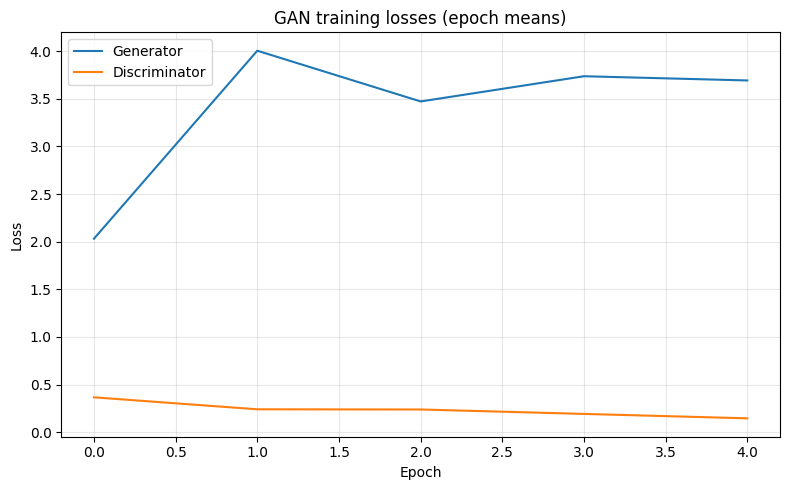

Epoch [06/50]  Loss_G: 3.9369  Loss_D: 0.1279
Epoch [07/50]  Loss_G: 3.8790  Loss_D: 0.1468
Epoch [08/50]  Loss_G: 3.6907  Loss_D: 0.1328
Epoch [09/50]  Loss_G: 3.2307  Loss_D: 0.1655
Epoch [10/50]  Loss_G: 2.8038  Loss_D: 0.2047


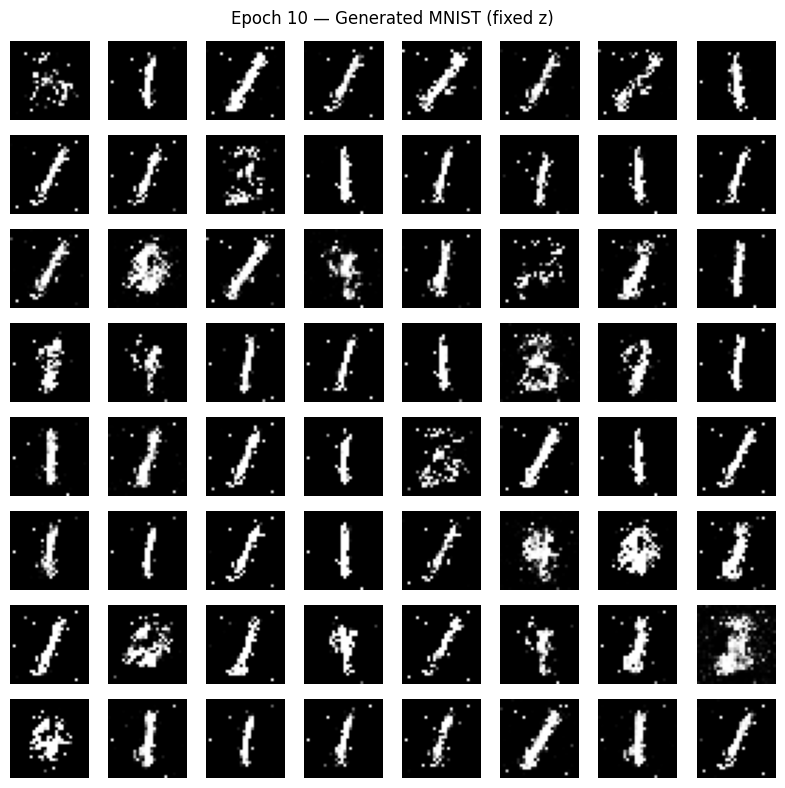

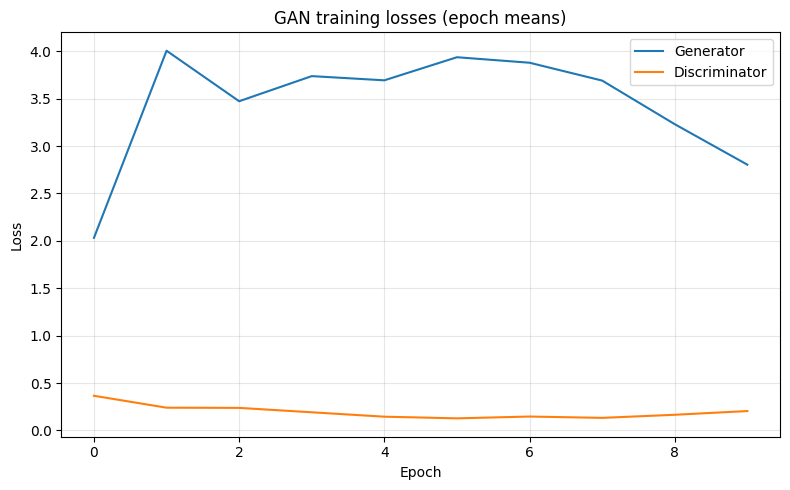

Epoch [11/50]  Loss_G: 2.3523  Loss_D: 0.2964
Epoch [12/50]  Loss_G: 2.0340  Loss_D: 0.3390
Epoch [13/50]  Loss_G: 1.8829  Loss_D: 0.3637
Epoch [14/50]  Loss_G: 1.8093  Loss_D: 0.3794
Epoch [15/50]  Loss_G: 1.8384  Loss_D: 0.3759


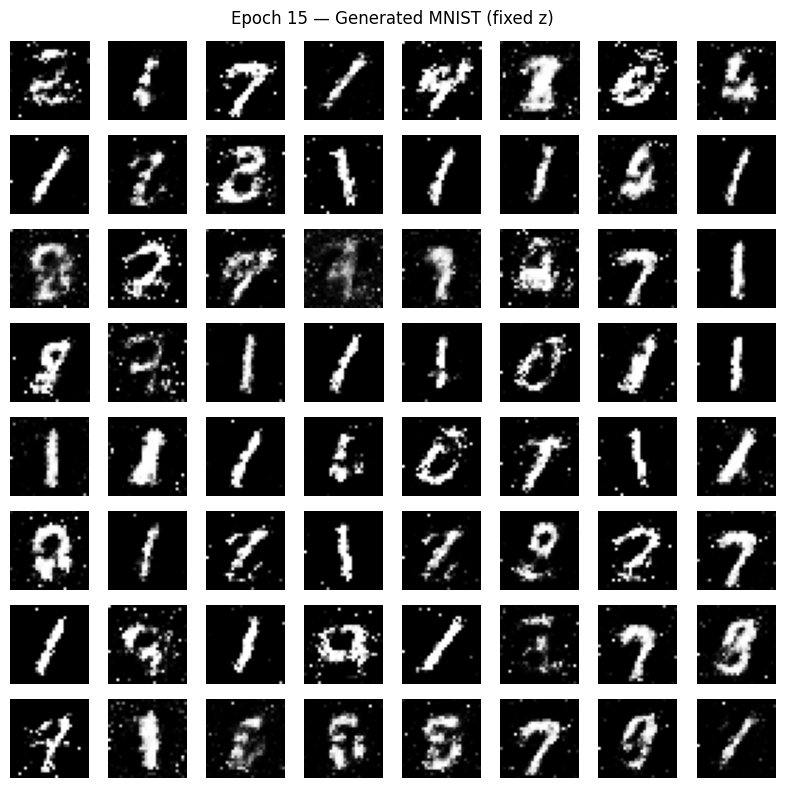

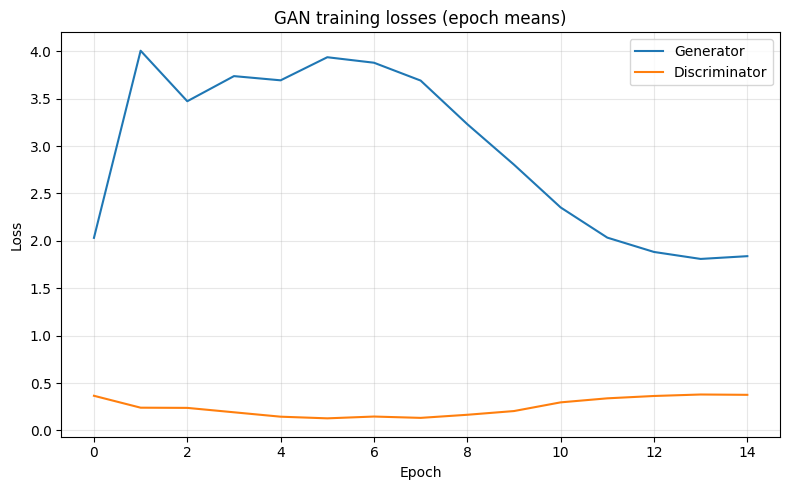

Epoch [16/50]  Loss_G: 1.8195  Loss_D: 0.3831


KeyboardInterrupt: 

In [ ]:
num_epochs = 50

loss_G_hist = []
loss_D_hist = []

fixed_z = torch.randn(64, nz, device=device)  # same noise for comparable snapshots

for epoch in range(1, num_epochs + 1):
    G.train()
    D.train()
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        bsz = real_images.size(0)

        # --- Labels ---
        real_labels = torch.ones(bsz, 1, device=device)
        fake_labels = torch.zeros(bsz, 1, device=device)

        # Optional mild label smoothing for real labels (D only) — uncomment to experiment:
        # label_smooth = 0.1
        # real_labels = real_labels * (1.0 - label_smooth) + 0.5 * label_smooth

        # =====================
        # (1) Update Discriminator
        # =====================
        optimizerD.zero_grad(set_to_none=True)

        # Real batch
        out_real = D(real_images)
        loss_real = criterion(out_real, real_labels)

        # Fake batch
        z = torch.randn(bsz, nz, device=device)
        fake_images = G(z).detach()
        out_fake = D(fake_images)
        loss_fake = criterion(out_fake, fake_labels)

        loss_D = (loss_real + loss_fake) / 2.0
        loss_D.backward()
        optimizerD.step()

        # =====================
        # (2) Update Generator
        # =====================
        optimizerG.zero_grad(set_to_none=True)
        z = torch.randn(bsz, nz, device=device)
        fake_images = G(z)
        out_fake_for_G = D(fake_images)
        loss_G = criterion(out_fake_for_G, real_labels)  # want D(fake) ~ 1
        loss_G.backward()
        optimizerG.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        num_batches += 1

    loss_G_hist.append(epoch_g_loss / num_batches)
    loss_D_hist.append(epoch_d_loss / num_batches)

    print(f"Epoch [{epoch:02d}/{num_epochs}]  Loss_G: {loss_G_hist[-1]:.4f}  Loss_D: {loss_D_hist[-1]:.4f}")

    if epoch % 5 == 0 or epoch == 1:
        # Snapshot with fixed noise
        G.eval()
        with torch.no_grad():
            fakes = G(fixed_z).cpu().view(64, 28, 28)
            fakes = denormalize_to_01(fakes.clamp(-1, 1))
        fig, axes = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(axes.flatten()):
            ax.imshow(fakes[i], cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
        plt.suptitle(f'Epoch {epoch} — Generated MNIST (fixed z)')
        plt.tight_layout()
        plt.show()
        G.train()

        # Loss curves
        plt.figure(figsize=(8, 5))
        plt.plot(loss_G_hist, label='Generator')
        plt.plot(loss_D_hist, label='Discriminator')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('GAN training losses (epoch means)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


### Interpreting results

- Early epochs often show **noisy** or **blurry** digits; later epochs should show **clearer** structure if training succeeds.
- **Loss curves are not like supervised learning:** there is **no single "lower is better"** rule for both curves simultaneously. Large **oscillation** can indicate imbalance between **D** and **G**.
- If **D** becomes too strong too fast, **G** may get **weak gradients** ("vanishing" signal). Remedies include **less frequent D updates**, **noise** to inputs, **architecture** changes, **WGAN**-style objectives (theory section), or **label smoothing**.

---


---

# Lab Exercises (Total: 100 points)

These tasks build on the tutorial code above. Each one asks for **small, concrete changes**—you mostly **copy** the training loop and change **one** setting at a time. Replace the **`pass`** in each code cell with your work (you can also add new cells).

| Task | Topic | Points |
|------|--------|--------|
| 1 | Slightly bigger Generator (one clear change) | 20 |
| 2 | Same GAN on Fashion-MNIST | 15 |
| 3 | Compare **two** learning rates | 35 |
| 4 | Label smoothing (real labels = 0.9) | 30 |
| | **Total** | **100** |


## Task 1 — Slightly bigger Generator (20 points)

**What to do:** Copy the tutorial `Generator` class. Change **only one** thing, for example:

- make the **first** hidden layer wider (e.g. `256` → `512`), **or**
- add **one** extra `Linear` + `LeakyReLU` block **before** the last layer that outputs 784.

Keep the **Discriminator** and **training settings** the same as the tutorial (`Adam`, `lr`, `batch_size`, etc.).

**Hand in:**

1. One or two sentences describing what you changed.
2. Train for **20** epochs if you can.
3. Show **one** 8×8 grid of **your** generated images at the **last** epoch (you may reuse the plotting code from the tutorial).
4. Two or three sentences: Do the samples look **better, worse, or about the same** as the tutorial? Any odd behavior?


**Hint:** Duplicate the tutorial cells in this section or copy the `Generator` + training loop here so you do not break your original MNIST run.


In [8]:
class Generator(nn.Module):
    def __init__(self, nz=100):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(nz, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

G = Generator(nz).to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

opt_d = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_g = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

for epoch in range(20):
    for i, (imgs, _) in enumerate(train_loader):
        curr_bs = imgs.size(0)
        real_imgs = imgs.to(device)
        real_label = torch.ones(curr_bs, 1).to(device)
        fake_label = torch.zeros(curr_bs, 1).to(device)

        opt_d.zero_grad()
        out_r = D(real_imgs)
        loss_r = criterion(out_r, real_label)
        noise = torch.randn(curr_bs, nz).to(device)
        fake_imgs = G(noise)
        out_f = D(fake_imgs.detach())
        loss_f = criterion(out_f, fake_label)
        d_loss = (loss_r + loss_f) / 2
        d_loss.backward()
        opt_d.step()

        opt_g.zero_grad()
        out_f2 = D(fake_imgs)
        g_loss = criterion(out_f2, real_label)
        g_loss.backward()
        opt_g.step()

G.eval()
with torch.no_grad():
    test_noise = torch.randn(64, nz).to(device)
    samples = G(test_noise).cpu().view(64, 28, 28)
    samples = (samples + 1) / 2

fig, ax = plt.subplots(8, 8, figsize=(6,6))
for i, idx in enumerate(ax.flat):
    idx.imshow(samples[i], cmap='gray')
    idx.axis('off')
plt.show()

Starting Task 1 Training...
Epoch [1/20] Loss_D: 0.3870 Loss_G: 1.8075


KeyboardInterrupt: 

**Grading (20 pts):** Clear one-line change + trained model + image grid + short comment.


## Task 2 — Fashion-MNIST (15 points)

**What to do:** Use **Fashion-MNIST** instead of MNIST. In `torchvision`, load `datasets.FashionMNIST` with the **same** `transform` as in the tutorial (flatten + scale to [-1, 1]). Keep the same `Generator`, `Discriminator`, and training code.

**Hand in:**

1. One small grid (e.g. 8×8) of **real** Fashion-MNIST images so we see the dataset.
2. One grid of **fake** images after training (**at least 25 epochs**; use 50 if you can).
3. Two sentences: Does your generator produce **recognizable** clothes/shoes, or mostly **blur/noise**? How does that compare to digits?


**Tip:** Create **new** variables (e.g. `train_loader_fashion`, `G_f`, `D_f`) so you do not overwrite the MNIST models.


In [ ]:
# TODO Task 2: FashionMNIST DataLoader + train + plot real grid + plot fake grid.
pass


In [ ]:
fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),
    transforms.Lambda(lambda x: 2.0 * x - 1.0)
])

f_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=fashion_transform)
f_loader = DataLoader(f_data, batch_size=128, shuffle=True)

real_batch, _ = next(iter(f_loader))
plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(real_batch[i].view(28,28), cmap='gray')
    plt.axis('off')
plt.show()

G_f = Generator().to(device)
D_f = Discriminator().to(device)
opt_df = optim.Adam(D_f.parameters(), lr=0.0002)
opt_gf = optim.Adam(G_f.parameters(), lr=0.0002)

for epoch in range(25):
    for imgs, _ in f_loader:
        b_size = imgs.size(0)
        real = imgs.to(device)
        opt_df.zero_grad()
        l_r = criterion(D_f(real), torch.ones(b_size, 1).to(device))
        fake = G_f(torch.randn(b_size, 100).to(device))
        l_f = criterion(D_f(fake.detach()), torch.zeros(b_size, 1).to(device))
        ((l_r + l_f)/2).backward()
        opt_df.step()

        opt_gf.zero_grad()
        criterion(D_f(fake), torch.ones(b_size, 1).to(device)).backward()
        opt_gf.step()

G_f.eval()
with torch.no_grad():
    fakes = G_f(torch.randn(64, 100).to(device)).cpu().view(64, 28, 28)
plt.figure(figsize=(6,6))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(fakes[i], cmap='gray')
    plt.axis('off')
plt.show()

**Grading (15 pts):** Correct dataset + training ran + two grids + two sentences.


## Task 3 — Compare two learning rates (20 points)

**What to do:** Train the **tutorial GAN twice**, everything the same except **learning rate**:

- **Run A:** `lr = 0.0002` (same as the tutorial).
- **Run B:** `lr = 0.0005` **or** `lr = 0.0001` (pick one).

Use `set_seed(42)` at the **start of each run** so results are comparable. Use the **same** number of epochs for both (e.g. **20** epochs is enough if 50 is slow).

**Hand in:**

1. **One** plot with **both** generator loss curves (`plt.plot` twice + `legend`).
2. **Print** the **last** generator loss for Run A and Run B.
3. Two or three sentences: Which run produced **clearer** digits in your grids (if any)?


**Reminder:** Re-create `G` and `D` (and optimizers) before each run so you start from fresh weights.


In [ ]:
def simple_train(lr_val):
    set_seed(42)
    g_net = Generator().to(device)
    d_net = Discriminator().to(device)
    g_opt = optim.Adam(g_net.parameters(), lr=lr_val)
    d_opt = optim.Adam(d_net.parameters(), lr=lr_val)
    loss_history = []
    for epoch in range(20):
        total_g_loss = 0
        for imgs, _ in train_loader:
            bs = imgs.size(0)
            d_opt.zero_grad()
            r_loss = criterion(d_net(imgs.to(device)), torch.ones(bs,1).to(device))
            f_imgs = g_net(torch.randn(bs, 100).to(device))
            f_loss = criterion(d_net(f_imgs.detach()), torch.zeros(bs,1).to(device))
            ((r_loss + f_loss)/2).backward()
            d_opt.step()
            g_opt.zero_grad()
            gl = criterion(d_net(f_imgs), torch.ones(bs,1).to(device))
            gl.backward()
            g_opt.step()
            total_g_loss += gl.item()
        loss_history.append(total_g_loss / len(train_loader))
    return loss_history

hist_a = simple_train(0.0002)
hist_b = simple_train(0.0005)
plt.plot(hist_a, label='lr 0.0002')
plt.plot(hist_b, label='lr 0.0005')
plt.legend()
plt.show()
print("Final G loss A:", hist_a[-1])
print("Final G loss B:", hist_b[-1])

**Grading (20 pts):** Two complete runs + one combined loss plot + printed final losses + short comment.


## Task 4 — Label smoothing for real images (15 points)

**Idea:** When training the **discriminator**, instead of telling it that **every real image** has label **1.0**, use a slightly smaller label, e.g. **0.9**. Fake images still use label **0**. This is called **one-sided label smoothing** and can make training a bit steadier.

**What to do:** Copy the training loop. Where you create `real_labels`, use **`torch.ones(...) * 0.9`** instead of **`torch.ones(...)`**. Train for **at least 25 epochs**.

**Hand in:**

1. Show **one** figure: either **generator loss** over epochs **or** an **8×8 grid** of generated images at the end.
2. Two or three sentences: Did training **feel** more stable (loss jumping less), or did images look **better/worse** than the tutorial? (It is OK if you see little difference.)


**Note:** Keep targets strictly between **0** and **1** (e.g. **0.9** for real, **0** for fake works with `BCELoss`).


In [ ]:
G4 = Generator().to(device)
D4 = Discriminator().to(device)
opt_g4 = optim.Adam(G4.parameters(), lr=0.0002)
opt_d4 = optim.Adam(D4.parameters(), lr=0.0002)
for epoch in range(25):
    for imgs, _ in train_loader:
        bs = imgs.size(0)
        opt_d4.zero_grad()
        loss_real = criterion(D4(imgs.to(device)), torch.ones(bs,1).to(device) * 0.9)
        fakes = G4(torch.randn(bs, 100).to(device))
        loss_fake = criterion(D4(fakes.detach()), torch.zeros(bs,1).to(device))
        ((loss_real + loss_fake)/2).backward()
        opt_d4.step()
        opt_g4.zero_grad()
        criterion(D4(fakes), torch.ones(bs,1).to(device)).backward()
        opt_g4.step()

G4.eval()
with torch.no_grad():
    res = G4(torch.randn(64, 100).to(device)).cpu().view(64,28,28)
plt.imshow(res[0], cmap='gray')
plt.show()

**Grading (15 pts):** Code runs + one figure + short written reflection.


---

# Bonus: Theoretical Questions (10% extra credit)


**Question 1 — Mode collapse:** In your own words, what is **mode collapse**? Give **one** reason it can happen and **one** idea to reduce it.

**Question 2 — Generator loss:** In this lab, the generator is trained so that **fake** images are labeled like **real** ones for the discriminator. What goes wrong if the discriminator becomes **too good** at spotting fakes early in training?

**Question 3 — Why two networks?** Why do we need **both** a generator and a discriminator? What would happen if we only trained a generator with a simple pixel-wise loss to match MNIST images?


### My answers

Q1 — Mode collapse

Mode collapse is when the generator gets lazy and just keeps making the same one or two pictures that the discriminator thinks are real. It stops trying to make different numbers. This happens because it found an easy way to win and got stuck. To fix it you could use something like WGAN or just change the layers up.

Q2 — Vanishing gradients

If the discriminator gets too good too fast the generator doesn't know how to improve because the loss stays the same. The math doesn't give it any direction to go so it just stops learning.

Q3 — Why two networks?

You need both so they can fight each other. If you only had a generator and tried to match pixels the pictures would be super blurry because the math just averages everything out. The discriminator makes the generator actually try to look real.